In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
df = pd.read_csv('../data/dataset.csv')
df

,filestem,patient_id,study_number,timehash,gender,age,laterality,projection,initial_exam,ao_classification,cast,diagnosis_uncertain,osteopenia,fracture_visible,metal,pixel_spacing,device_manufacturer
0,0001_1297860395_01_WRI-L1_M014,1,1,1297860395,M,14.1,L,1,1.0,23r-M/2.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
1,0001_1297860435_01_WRI-L2_M014,1,1,1297860435,M,14.1,L,2,1.0,23r-M/2.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
2,0002_0354485735_01_WRI-R1_F012,2,1,354485735,F,12.0,R,1,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
3,0002_0354485759_01_WRI-R2_F012,2,1,354485759,F,12.0,R,2,1.0,23r-M/2.1,NaN,1.0,NaN,NaN,NaN,0.144,Siemens
4,0003_0662359226_01_WRI-R1_M011,3,1,662359226,M,11.1,R,1,1.0,23-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20322,6091_0590289015_02_WRI-L2_F008,6091,2,590289015,F,8.7,L,2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
20323,6092_0295935784_01_WRI-L1_M003,6092,1,295935784,M,3.5,L,1,1.0,22-D/1.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
20324,6092_0295935837_01_WRI-L2_M003,6092,1,295935837,M,3.5,L,2,1.0,22-D/1.1,NaN,NaN,NaN,NaN,NaN,0.144,Siemens
20325,6093_0885712402_01_WRI-L1_M008,6093,1,885712402,M,8.4,L,1,1.0,23r-M/3.1,NaN,NaN,NaN,1.0,NaN,0.144,Siemens


In [6]:
df.shape

(20327, 17)

In [7]:
df.dtypes


filestem                object
patient_id               int64
study_number             int64
timehash                 int64
gender                  object
age                    float64
laterality              object
projection               int64
initial_exam           float64
ao_classification       object
cast                   float64
diagnosis_uncertain    float64
osteopenia             float64
fracture_visible       float64
metal                  float64
pixel_spacing          float64
device_manufacturer     object
dtype: object

In [8]:
df.isnull().sum()

filestem                   0
patient_id                 0
study_number               0
timehash                   0
gender                     0
age                        0
laterality                 0
projection                 0
initial_exam            9466
ao_classification       6169
cast                   14551
diagnosis_uncertain    19790
osteopenia             17854
fracture_visible        6777
metal                  19619
pixel_spacing              0
device_manufacturer        0
dtype: int64

20.327 imágenes, 17 columnas — coincide con lo esperado
patient_id es int64 y sin nulls — perfecto para el split
Columnas binarias como fracture_visible, cast, metal tienen muchos nulls — probablemente null significa 0 (ausencia)
diagnosis_uncertain tiene 19.790 nulls sobre 20.327 — casi siempre ausente
ao_classification tiene 6.169 nulls — no todas las fracturas tienen clasificación

In [9]:
df['patient_id'].nunique()

6091

Entonces tenemos 6.091 pacientes únicos con 20.327 imágenes — un promedio de ~3.3 imágenes por paciente.
Con el split 70/10/20 quedaría:

Train: ~4.264 pacientes
Val: ~609 pacientes
Test: ~1.218 pacientes

In [10]:
df.groupby('patient_id').size().describe()

count    6091.000000
mean        3.337219
std         2.533628
min         1.000000
25%         2.000000
50%         2.000000
75%         4.000000
max        30.000000
dtype: float64

In [11]:
df.groupby('patient_id').size().value_counts().sort_index()

1       96
2     4064
3       31
4      780
5       17
6      477
7       15
8      329
9        8
10     165
11       6
12      62
13       1
14      17
15       3
16      10
18       3
20       2
22       2
24       1
26       1
30       1
Name: count, dtype: int64

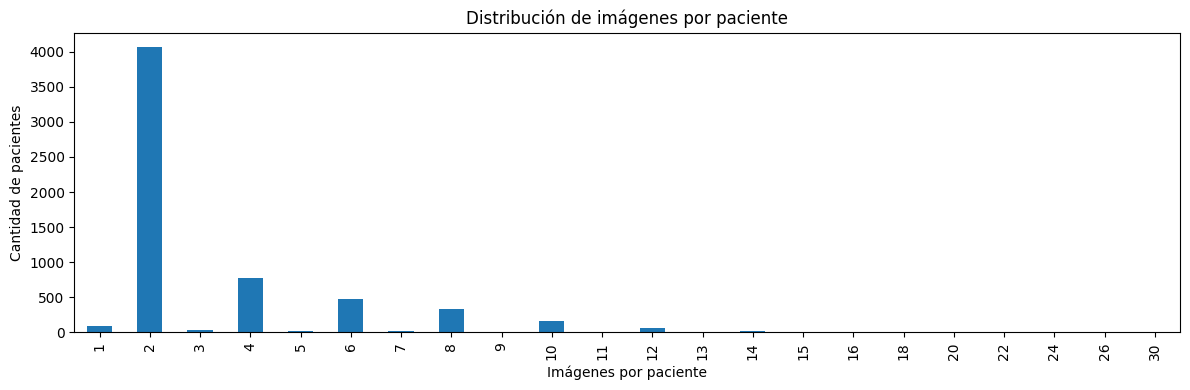

In [12]:
df.groupby('patient_id').size().value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.xlabel('Imágenes por paciente')
plt.ylabel('Cantidad de pacientes')
plt.title('Distribución de imágenes por paciente')
plt.tight_layout()

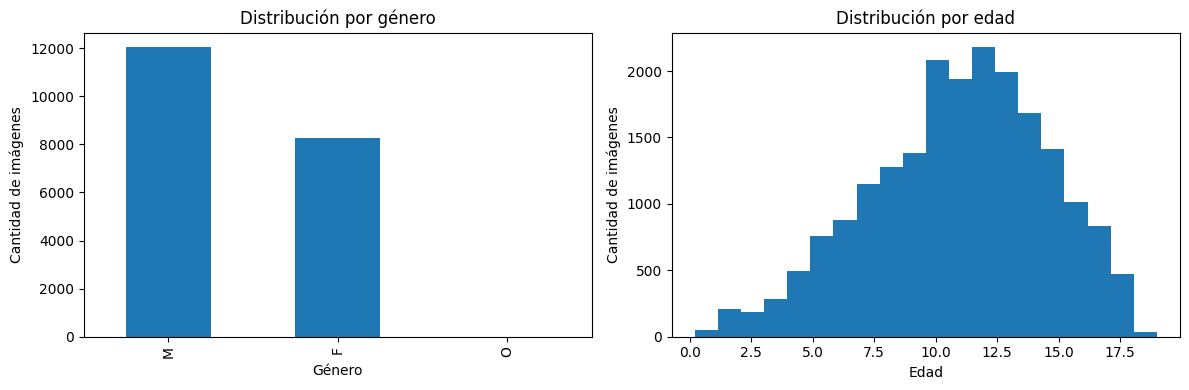

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['gender'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución por género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de imágenes')

df['age'].plot(kind='hist', bins=20, ax=axes[1])
axes[1].set_title('Distribución por edad')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Cantidad de imágenes')

plt.tight_layout()